# HW10-11
## Часть A: классификация изображений (STL10)
## Часть B: segmentation (OxfordIIITPet)

In [1]:
import os
import json
import copy
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models
from torchvision.transforms import InterpolationMode
from torchvision.models import ResNet18_Weights
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["image.cmap"] = "gray"

In [3]:
cwd = Path.cwd()

if cwd.name == "HW10-11" and cwd.parent.name == "homeworks":
    REPO_ROOT = cwd.parent.parent
else:
    REPO_ROOT = cwd

HW_DIR = REPO_ROOT / "homeworks" / "HW10-11"
ART_DIR = HW_DIR / "artifacts"
FIG_DIR = ART_DIR / "figures"
DATA_DIR = REPO_ROOT / "data"

for p in [HW_DIR, ART_DIR, FIG_DIR, DATA_DIR]:
    p.mkdir(parents=True, exist_ok=True)

SEED = 42

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("REPO_ROOT =", REPO_ROOT)
print("HW_DIR    =", HW_DIR)
print("ART_DIR   =", ART_DIR)
print("FIG_DIR   =", FIG_DIR)
print("DATA_DIR  =", DATA_DIR)
print("DEVICE    =", device)

REPO_ROOT = C:\Users\andre\OneDrive\Документы\DPO\AIE\AIE-1
HW_DIR    = C:\Users\andre\OneDrive\Документы\DPO\AIE\AIE-1\homeworks\HW10-11
ART_DIR   = C:\Users\andre\OneDrive\Документы\DPO\AIE\AIE-1\homeworks\HW10-11\artifacts
FIG_DIR   = C:\Users\andre\OneDrive\Документы\DPO\AIE\AIE-1\homeworks\HW10-11\artifacts\figures
DATA_DIR  = C:\Users\andre\OneDrive\Документы\DPO\AIE\AIE-1\data
DEVICE    = cpu


In [4]:
CFG = {
    "seed": SEED,
    "batch_size": 64,
    "num_workers": 2 if os.name != "nt" else 0,
    "pin_memory": torch.cuda.is_available(),

    # часть A
    "cnn_epochs": 10,
    "resnet_epochs": 6,
    "cnn_lr": 1e-3,
    "resnet_head_lr": 1e-3,
    "resnet_ft_lr": 1e-4,

    # часть B
    "seg_eval_max_samples": None,
}

print(CFG)

{'seed': 42, 'batch_size': 64, 'num_workers': 0, 'pin_memory': False, 'cnn_epochs': 10, 'resnet_epochs': 6, 'cnn_lr': 0.001, 'resnet_head_lr': 0.001, 'resnet_ft_lr': 0.0001, 'seg_eval_max_samples': None}


In [5]:
# Базовые трансформации для простой CNN
cnn_base_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# Аугментации для C2
cnn_aug_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# Превью аугментаций без нормализации, только для красивой картинки
cnn_aug_preview_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
])

# Pretrained transforms для ResNet18
resnet_weights = ResNet18_Weights.DEFAULT
resnet_transform = resnet_weights.transforms()

print("Transforms are ready.")

Transforms are ready.


In [6]:
class TransformSubset(Dataset):
    def __init__(self, base_dataset, indices=None, transform=None, target_transform=None):
        self.base_dataset = base_dataset
        self.indices = list(range(len(base_dataset))) if indices is None else list(indices)
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x, y = self.base_dataset[self.indices[idx]]
        if self.transform is not None:
            x = self.transform(x)
        if self.target_transform is not None:
            y = self.target_transform(y)
        return x, y

In [7]:
# Официальные split у STL10: train и test.
# Для val делаем свой split из train с фиксированным seed.

stl10_train_raw = datasets.STL10(root=DATA_DIR, split="train", download=True)
stl10_test_raw = datasets.STL10(root=DATA_DIR, split="test", download=True)

num_classes = 10
class_names = stl10_train_raw.classes

indices = np.arange(len(stl10_train_raw))
rng = np.random.default_rng(SEED)
rng.shuffle(indices)

train_size = int(0.8 * len(indices))
train_idx = indices[:train_size]
val_idx = indices[train_size:]

print("STL10 train total:", len(stl10_train_raw))
print("Train split:", len(train_idx))
print("Val split  :", len(val_idx))
print("Test split :", len(stl10_test_raw))
print("Classes    :", class_names)

100.0%


STL10 train total: 5000
Train split: 4000
Val split  : 1000
Test split : 8000
Classes    : ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [8]:
def make_classification_loaders(train_transform, eval_transform):
    train_ds = TransformSubset(stl10_train_raw, train_idx, transform=train_transform)
    val_ds = TransformSubset(stl10_train_raw, val_idx, transform=eval_transform)
    test_ds = TransformSubset(stl10_test_raw, None, transform=eval_transform)

    train_loader = DataLoader(
        train_ds,
        batch_size=CFG["batch_size"],
        shuffle=True,
        num_workers=CFG["num_workers"],
        pin_memory=CFG["pin_memory"],
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=CFG["batch_size"],
        shuffle=False,
        num_workers=CFG["num_workers"],
        pin_memory=CFG["pin_memory"],
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=CFG["batch_size"],
        shuffle=False,
        num_workers=CFG["num_workers"],
        pin_memory=CFG["pin_memory"],
    )
    return train_loader, val_loader, test_loader

In [9]:
train_loader_preview, val_loader_preview, test_loader_preview = make_classification_loaders(
    train_transform=cnn_base_transform,
    eval_transform=cnn_base_transform,
)

xb, yb = next(iter(train_loader_preview))
print("Batch x.shape:", xb.shape)
print("Batch y.shape:", yb.shape)
print("Batch dtype  :", xb.dtype, yb.dtype)
print("Labels sample:", yb[:10].tolist())

Batch x.shape: torch.Size([64, 3, 96, 96])
Batch y.shape: torch.Size([64])
Batch dtype  : torch.float32 torch.int64
Labels sample: [0, 8, 6, 9, 4, 7, 7, 0, 5, 5]


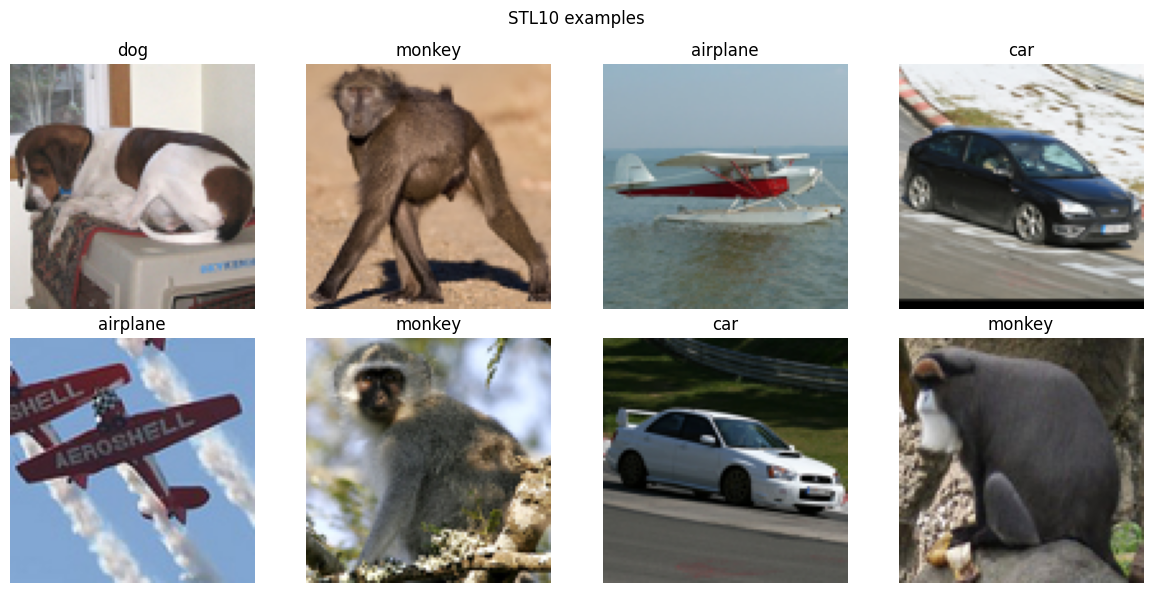

In [10]:
def denorm_img(x):
    x = x.clone()
    x = x * 0.5 + 0.5
    return x.clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, idx in zip(axes.flatten(), range(8)):
    img, label = TransformSubset(stl10_train_raw, train_idx, transform=cnn_base_transform)[idx]
    img = denorm_img(img).permute(1, 2, 0).cpu().numpy()
    ax.imshow(img)
    ax.set_title(class_names[label])
    ax.axis("off")

plt.suptitle("STL10 examples")
plt.tight_layout()
plt.show()

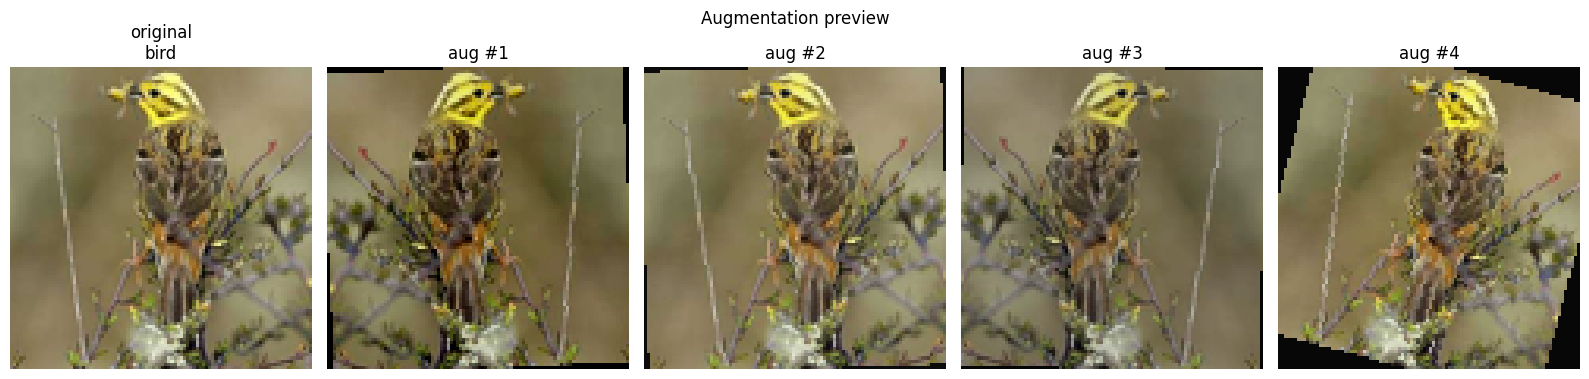

Saved: C:\Users\andre\OneDrive\Документы\DPO\AIE\AIE-1\homeworks\HW10-11\artifacts\figures\augmentations_preview.png


In [11]:
orig_img, orig_label = stl10_train_raw[0]

fig, axes = plt.subplots(1, 5, figsize=(16, 4))

axes[0].imshow(orig_img)
axes[0].set_title(f"original\n{class_names[orig_label]}")
axes[0].axis("off")

for i in range(1, 5):
    aug_img = cnn_aug_preview_transform(orig_img)
    axes[i].imshow(aug_img)
    axes[i].set_title(f"aug #{i}")
    axes[i].axis("off")

plt.suptitle("Augmentation preview")
plt.tight_layout()
plt.savefig(FIG_DIR / "augmentations_preview.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", FIG_DIR / "augmentations_preview.png")

In [12]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [13]:
def build_simple_cnn(num_classes):
    return SimpleCNN(num_classes=num_classes)

def build_resnet18_head_only(num_classes):
    model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
    for p in model.parameters():
        p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def build_resnet18_finetune(num_classes):
    model = models.resnet18(weights=ResNet18_Weights.DEFAULT)

    for p in model.parameters():
        p.requires_grad = False

    # partial fine-tune: layer4 + fc
    for p in model.layer4.parameters():
        p.requires_grad = True

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

In [14]:
def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_count += xb.size(0)

    return {
        "loss": total_loss / total_count,
        "accuracy": total_correct / total_count,
    }

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        total_loss += loss.item() * xb.size(0)
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_count += xb.size(0)

    return {
        "loss": total_loss / total_count,
        "accuracy": total_correct / total_count,
    }

def fit_classification_experiment(model, train_loader, val_loader, epochs, lr, device):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    history = []
    best_val_acc = -1.0
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(1, epochs + 1):
        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_metrics = evaluate(model, val_loader, criterion, device)

        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
        }
        history.append(row)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={row['train_loss']:.4f} | train_acc={row['train_accuracy']:.4f} | "
            f"val_loss={row['val_loss']:.4f} | val_acc={row['val_accuracy']:.4f}"
        )

        if row["val_accuracy"] > best_val_acc:
            best_val_acc = row["val_accuracy"]
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    return {
        "model": model,
        "history": history,
        "best_state": best_state,
        "best_val_accuracy": best_val_acc,
        "optimizer_name": "Adam",
    }

In [15]:
classification_experiments = [
    {
        "experiment_id": "C1",
        "task": "classification",
        "name": "simple-cnn-base",
        "model_builder": lambda: build_simple_cnn(num_classes),
        "train_transform": cnn_base_transform,
        "eval_transform": cnn_base_transform,
        "epochs": CFG["cnn_epochs"],
        "lr": CFG["cnn_lr"],
        "model_summary": "SimpleCNN, no augmentations",
        "notes": "baseline CNN",
    },
    {
        "experiment_id": "C2",
        "task": "classification",
        "name": "simple-cnn-aug",
        "model_builder": lambda: build_simple_cnn(num_classes),
        "train_transform": cnn_aug_transform,
        "eval_transform": cnn_base_transform,
        "epochs": CFG["cnn_epochs"],
        "lr": CFG["cnn_lr"],
        "model_summary": "SimpleCNN, augmented train",
        "notes": "same CNN as C1, only train augmentations changed",
    },
    {
        "experiment_id": "C3",
        "task": "classification",
        "name": "resnet18-head-only",
        "model_builder": lambda: build_resnet18_head_only(num_classes),
        "train_transform": resnet_transform,
        "eval_transform": resnet_transform,
        "epochs": CFG["resnet_epochs"],
        "lr": CFG["resnet_head_lr"],
        "model_summary": "ResNet18 pretrained, backbone frozen, fc only",
        "notes": "head-only transfer learning",
    },
    {
        "experiment_id": "C4",
        "task": "classification",
        "name": "resnet18-finetune",
        "model_builder": lambda: build_resnet18_finetune(num_classes),
        "train_transform": resnet_transform,
        "eval_transform": resnet_transform,
        "epochs": CFG["resnet_epochs"],
        "lr": CFG["resnet_ft_lr"],
        "model_summary": "ResNet18 pretrained, layer4 + fc trainable",
        "notes": "partial fine-tuning",
    },
]

In [16]:
classification_rows = []
classification_histories = {}
best_payload = None

for exp in classification_experiments:
    print("=" * 80)
    print(f"Running {exp['experiment_id']} — {exp['name']}")

    train_loader, val_loader, test_loader = make_classification_loaders(
        train_transform=exp["train_transform"],
        eval_transform=exp["eval_transform"],
    )

    model = exp["model_builder"]()

    result = fit_classification_experiment(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=exp["epochs"],
        lr=exp["lr"],
        device=device,
    )

    classification_histories[exp["experiment_id"]] = result["history"]

    row = {
        "experiment_id": exp["experiment_id"],
        "task": exp["task"],
        "dataset": "STL10",
        "seed": SEED,
        "model_summary": exp["model_summary"],
        "optimizer": result["optimizer_name"],
        "lr": exp["lr"],
        "epochs_trained": exp["epochs"],
        "best_val_accuracy": result["best_val_accuracy"],
        "test_accuracy": np.nan,   # test считаем только один раз потом
        "precision": np.nan,
        "recall": np.nan,
        "mean_iou": np.nan,
        "notes": exp["notes"],
    }
    classification_rows.append(row)

    if (best_payload is None) or (result["best_val_accuracy"] > best_payload["best_val_accuracy"]):
        best_payload = {
            "experiment_id": exp["experiment_id"],
            "name": exp["name"],
            "model_builder": exp["model_builder"],
            "state_dict": result["best_state"],
            "best_val_accuracy": result["best_val_accuracy"],
            "eval_transform": exp["eval_transform"],
            "train_transform_name": str(exp["train_transform"]),
            "eval_transform_name": str(exp["eval_transform"]),
            "epochs": exp["epochs"],
            "lr": exp["lr"],
            "model_summary": exp["model_summary"],
        }

print("\nClassification experiments finished.")
print("Best by val_accuracy:", best_payload["experiment_id"], best_payload["name"])
print("best_val_accuracy   :", best_payload["best_val_accuracy"])

Running C1 — simple-cnn-base
Epoch 01/10 | train_loss=1.8415 | train_acc=0.3108 | val_loss=1.7546 | val_acc=0.3470
Epoch 02/10 | train_loss=1.5943 | train_acc=0.3822 | val_loss=1.5140 | val_acc=0.4270
Epoch 03/10 | train_loss=1.4785 | train_acc=0.4407 | val_loss=1.4222 | val_acc=0.4630
Epoch 04/10 | train_loss=1.3860 | train_acc=0.4825 | val_loss=1.4292 | val_acc=0.4630
Epoch 05/10 | train_loss=1.2976 | train_acc=0.5278 | val_loss=1.2972 | val_acc=0.5250
Epoch 06/10 | train_loss=1.2257 | train_acc=0.5545 | val_loss=1.3040 | val_acc=0.5160
Epoch 07/10 | train_loss=1.1772 | train_acc=0.5693 | val_loss=1.4252 | val_acc=0.4770
Epoch 08/10 | train_loss=1.1294 | train_acc=0.5952 | val_loss=1.2061 | val_acc=0.5670
Epoch 09/10 | train_loss=1.0755 | train_acc=0.6075 | val_loss=1.2022 | val_acc=0.5710
Epoch 10/10 | train_loss=1.0168 | train_acc=0.6380 | val_loss=1.1971 | val_acc=0.5490
Running C2 — simple-cnn-aug
Epoch 01/10 | train_loss=1.8714 | train_acc=0.2980 | val_loss=1.6830 | val_acc=0.35

100.0%


Epoch 01/6 | train_loss=1.0929 | train_acc=0.7192 | val_loss=0.5021 | val_acc=0.8860
Epoch 02/6 | train_loss=0.3869 | train_acc=0.9187 | val_loss=0.3343 | val_acc=0.9160
Epoch 03/6 | train_loss=0.2730 | train_acc=0.9375 | val_loss=0.2829 | val_acc=0.9230
Epoch 04/6 | train_loss=0.2338 | train_acc=0.9407 | val_loss=0.2617 | val_acc=0.9190
Epoch 05/6 | train_loss=0.2023 | train_acc=0.9483 | val_loss=0.2471 | val_acc=0.9220
Epoch 06/6 | train_loss=0.1806 | train_acc=0.9540 | val_loss=0.2303 | val_acc=0.9230
Running C4 — resnet18-finetune
Epoch 01/6 | train_loss=0.6201 | train_acc=0.8325 | val_loss=0.2414 | val_acc=0.9380
Epoch 02/6 | train_loss=0.1193 | train_acc=0.9778 | val_loss=0.1951 | val_acc=0.9410
Epoch 03/6 | train_loss=0.0422 | train_acc=0.9972 | val_loss=0.1720 | val_acc=0.9500
Epoch 04/6 | train_loss=0.0193 | train_acc=1.0000 | val_loss=0.1702 | val_acc=0.9460
Epoch 05/6 | train_loss=0.0124 | train_acc=1.0000 | val_loss=0.1668 | val_acc=0.9500
Epoch 06/6 | train_loss=0.0074 | t

In [17]:
best_model = best_payload["model_builder"]().to(device)
best_model.load_state_dict(best_payload["state_dict"])

_, _, best_test_loader = make_classification_loaders(
    train_transform=best_payload["eval_transform"],
    eval_transform=best_payload["eval_transform"],
)

criterion = nn.CrossEntropyLoss()
best_test_metrics = evaluate(best_model, best_test_loader, criterion, device)

for row in classification_rows:
    if row["experiment_id"] == best_payload["experiment_id"]:
        row["test_accuracy"] = best_test_metrics["accuracy"]

print("Final TEST metrics for the best classifier:")
print(best_test_metrics)

Final TEST metrics for the best classifier:
{'loss': 0.16691075283288956, 'accuracy': 0.94775}


In [18]:
torch.save(best_payload["state_dict"], ART_DIR / "best_classifier.pt")

best_classifier_config = {
    "dataset": "STL10",
    "seed": SEED,
    "best_experiment_id": best_payload["experiment_id"],
    "best_experiment_name": best_payload["name"],
    "model_summary": best_payload["model_summary"],
    "best_val_accuracy": best_payload["best_val_accuracy"],
    "test_accuracy": best_test_metrics["accuracy"],
    "epochs": best_payload["epochs"],
    "lr": best_payload["lr"],
    "train_transform": best_payload["train_transform_name"],
    "eval_transform": best_payload["eval_transform_name"],
}

with open(ART_DIR / "best_classifier_config.json", "w", encoding="utf-8") as f:
    json.dump(best_classifier_config, f, ensure_ascii=False, indent=2)

print("Saved:", ART_DIR / "best_classifier.pt")
print("Saved:", ART_DIR / "best_classifier_config.json")

Saved: C:\Users\andre\OneDrive\Документы\DPO\AIE\AIE-1\homeworks\HW10-11\artifacts\best_classifier.pt
Saved: C:\Users\andre\OneDrive\Документы\DPO\AIE\AIE-1\homeworks\HW10-11\artifacts\best_classifier_config.json


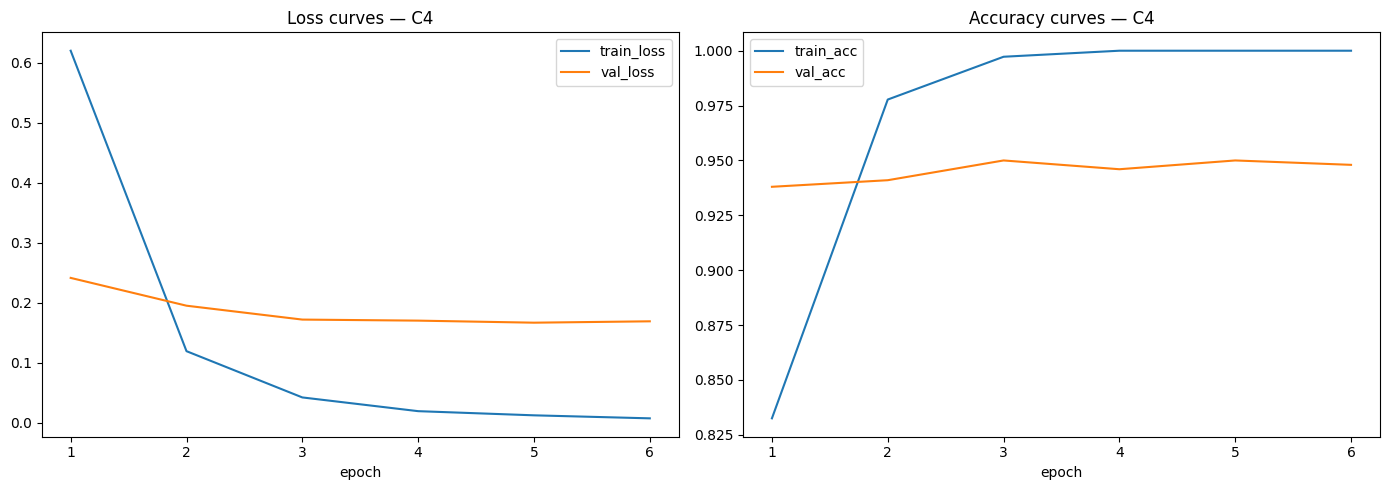

Saved: C:\Users\andre\OneDrive\Документы\DPO\AIE\AIE-1\homeworks\HW10-11\artifacts\figures\classification_curves_best.png


In [19]:
best_history = pd.DataFrame(classification_histories[best_payload["experiment_id"]])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(best_history["epoch"], best_history["train_loss"], label="train_loss")
axes[0].plot(best_history["epoch"], best_history["val_loss"], label="val_loss")
axes[0].set_title(f"Loss curves — {best_payload['experiment_id']}")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(best_history["epoch"], best_history["train_accuracy"], label="train_acc")
axes[1].plot(best_history["epoch"], best_history["val_accuracy"], label="val_acc")
axes[1].set_title(f"Accuracy curves — {best_payload['experiment_id']}")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "classification_curves_best.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", FIG_DIR / "classification_curves_best.png")

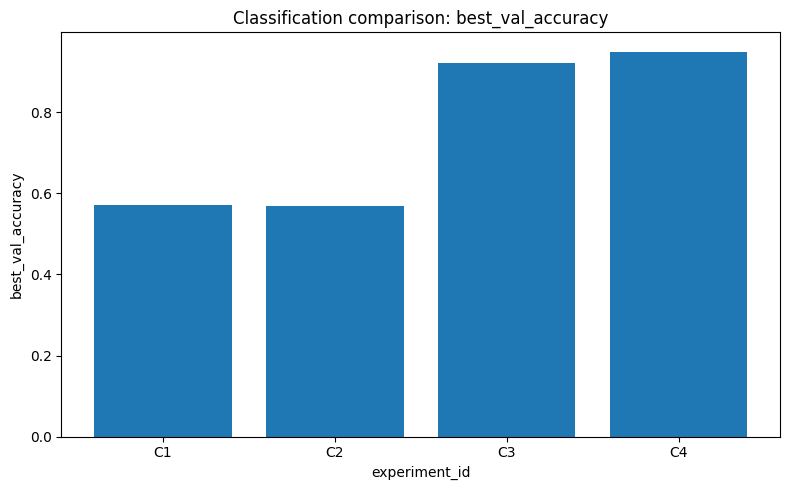

  experiment_id                                  model_summary  \
0            C1                    SimpleCNN, no augmentations   
1            C2                     SimpleCNN, augmented train   
2            C3  ResNet18 pretrained, backbone frozen, fc only   
3            C4     ResNet18 pretrained, layer4 + fc trainable   

   best_val_accuracy  test_accuracy  
0              0.571            NaN  
1              0.570            NaN  
2              0.923            NaN  
3              0.950        0.94775  
Saved: C:\Users\andre\OneDrive\Документы\DPO\AIE\AIE-1\homeworks\HW10-11\artifacts\figures\classification_compare.png


In [20]:
df_cls = pd.DataFrame(classification_rows)

plt.figure(figsize=(8, 5))
plt.bar(df_cls["experiment_id"], df_cls["best_val_accuracy"])
plt.title("Classification comparison: best_val_accuracy")
plt.xlabel("experiment_id")
plt.ylabel("best_val_accuracy")
plt.tight_layout()
plt.savefig(FIG_DIR / "classification_compare.png", dpi=150, bbox_inches="tight")
plt.show()

print(df_cls[["experiment_id", "model_summary", "best_val_accuracy", "test_accuracy"]])
print("Saved:", FIG_DIR / "classification_compare.png")

In [21]:
seg_weights = DeepLabV3_ResNet50_Weights.DEFAULT
seg_preprocess = seg_weights.transforms()

pet_test_ds = datasets.OxfordIIITPet(
    root=DATA_DIR,
    split="test",
    target_types="segmentation",
    download=True,
)

seg_categories = seg_weights.meta["categories"]
cat_class_idx = seg_categories.index("cat")
dog_class_idx = seg_categories.index("dog")

print("OxfordIIITPet test size:", len(pet_test_ds))
print("DeepLab categories size:", len(seg_categories))
print("cat idx:", cat_class_idx, "| dog idx:", dog_class_idx)

100.0%
100.0%


OxfordIIITPet test size: 3669
DeepLab categories size: 21
cat idx: 8 | dog idx: 12


Image size : (300, 225)
Mask size  : (300, 225)
Mask values: [1 2 3]


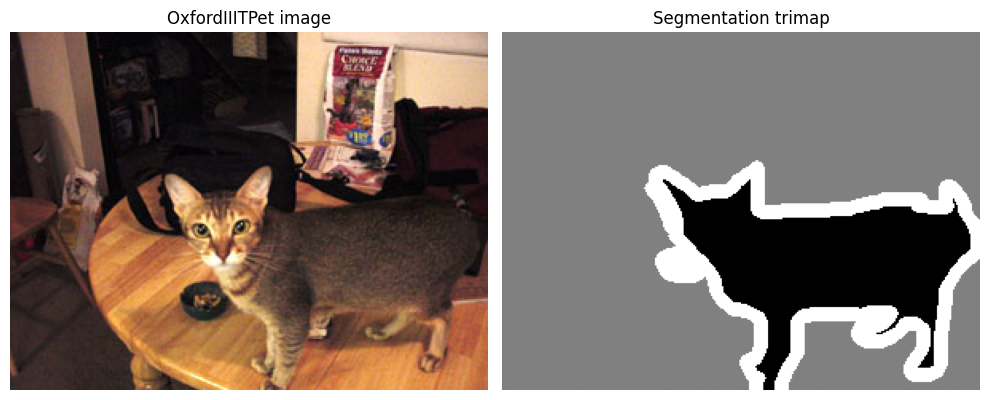

In [22]:
img0, trimap0 = pet_test_ds[0]
trimap0_np = np.array(trimap0)

print("Image size :", img0.size)
print("Mask size  :", trimap0.size)
print("Mask values:", np.unique(trimap0_np))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img0)
axes[0].set_title("OxfordIIITPet image")
axes[0].axis("off")

axes[1].imshow(trimap0_np)
axes[1].set_title("Segmentation trimap")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [23]:
seg_model = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.DEFAULT).to(device)
seg_model.eval()

print("Segmentation model is ready.")

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to C:\Users\andre/.cache\torch\hub\checkpoints\deeplabv3_resnet50_coco-cd0a2569.pth


100.0%


Segmentation model is ready.


In [24]:
def trimap_to_gt_and_valid(trimap_pil):
    """
    Oxford-IIIT Pet обычно используется как trimap:
    1 = pet, 2 = background, 3 = border.
    Для аккуратной бинарной оценки:
    - foreground = pet
    - border игнорируем в метрике
    """
    trimap = np.array(trimap_pil, dtype=np.uint8)

    gt_foreground = (trimap == 1)
    valid_mask = (trimap != 3)

    return torch.from_numpy(gt_foreground), torch.from_numpy(valid_mask)

@torch.no_grad()
def predict_pet_probability(model, pil_img):
    x = seg_preprocess(pil_img).unsqueeze(0).to(device)   # [1, C, H, W]
    out = model(x)["out"][0]                              # [num_classes, h, w]
    probs = out.softmax(dim=0)

    # Объединяем вероятности классов cat и dog как "pet foreground"
    pet_prob = probs[cat_class_idx] + probs[dog_class_idx]

    # Возвращаем к исходному размеру картинки / mask
    h, w = pil_img.size[1], pil_img.size[0]
    pet_prob = F.interpolate(
        pet_prob.unsqueeze(0).unsqueeze(0),
        size=(h, w),
        mode="bilinear",
        align_corners=False
    )[0, 0].cpu()

    return pet_prob

def morph_open_close(binary_mask_2d):
    """
    Простая морфологическая очистка через max_pool2d, без внешних библиотек.
    binary_mask_2d: torch.Tensor [H, W], значения 0/1
    """
    x = binary_mask_2d.float().unsqueeze(0).unsqueeze(0)

    # erosion = 1 - maxpool(1 - x)
    eroded = 1.0 - F.max_pool2d(1.0 - x, kernel_size=3, stride=1, padding=1)
    opened = F.max_pool2d(eroded, kernel_size=3, stride=1, padding=1)

    dilated = F.max_pool2d(opened, kernel_size=3, stride=1, padding=1)
    closed = 1.0 - F.max_pool2d(1.0 - dilated, kernel_size=3, stride=1, padding=1)

    return (closed[0, 0] > 0.5).to(torch.uint8)

def postprocess_v1(prob_map):
    # базовый режим
    return (prob_map >= 0.5).to(torch.uint8)

def postprocess_v2(prob_map):
    # альтернативный режим: более строгий threshold + морфологическая очистка
    raw = (prob_map >= 0.6).to(torch.uint8)
    return morph_open_close(raw)

def compute_binary_metrics(pred_mask, gt_fg, valid_mask=None):
    pred = pred_mask.bool()
    gt = gt_fg.bool()

    if valid_mask is not None:
        valid = valid_mask.bool()
        pred = pred[valid]
        gt = gt[valid]

    tp = (pred & gt).sum().item()
    fp = (pred & ~gt).sum().item()
    fn = (~pred & gt).sum().item()
    union = (pred | gt).sum().item()
    intersection = (pred & gt).sum().item()

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    mean_iou = intersection / (union + 1e-8)

    return {
        "precision": precision,
        "recall": recall,
        "mean_iou": mean_iou,
        "tp": tp,
        "fp": fp,
        "fn": fn,
    }

def overlay_mask(image_pil, binary_mask, color=(255, 0, 0), alpha=0.4):
    image = np.array(image_pil).astype(np.float32)
    mask = binary_mask.astype(bool)

    overlay = image.copy()
    overlay[mask] = np.array(color, dtype=np.float32)

    mixed = image.copy()
    mixed[mask] = (1 - alpha) * image[mask] + alpha * overlay[mask]
    return mixed.astype(np.uint8)

In [25]:
@torch.no_grad()
def evaluate_segmentation_mode(dataset, model, postprocess_fn, max_samples=None):
    ious = []
    precisions = []
    recalls = []
    examples = []

    n = len(dataset) if max_samples is None else min(max_samples, len(dataset))

    for idx in range(n):
        pil_img, trimap = dataset[idx]

        prob = predict_pet_probability(model, pil_img)
        pred = postprocess_fn(prob)

        gt_fg, valid = trimap_to_gt_and_valid(trimap)
        metrics = compute_binary_metrics(pred, gt_fg, valid)

        ious.append(metrics["mean_iou"])
        precisions.append(metrics["precision"])
        recalls.append(metrics["recall"])

        if len(examples) < 3:
            examples.append({
                "image": pil_img,
                "gt": gt_fg.numpy(),
                "pred": pred.numpy(),
                "prob": prob.numpy(),
            })

        if (idx + 1) % 100 == 0:
            print(f"Processed {idx + 1}/{n}")

    return {
        "mean_iou": float(np.mean(ious)),
        "precision": float(np.mean(precisions)),
        "recall": float(np.mean(recalls)),
        "examples": examples,
        "num_samples": n,
    }

seg_v1 = evaluate_segmentation_mode(
    dataset=pet_test_ds,
    model=seg_model,
    postprocess_fn=postprocess_v1,
    max_samples=CFG["seg_eval_max_samples"],
)

seg_v2 = evaluate_segmentation_mode(
    dataset=pet_test_ds,
    model=seg_model,
    postprocess_fn=postprocess_v2,
    max_samples=CFG["seg_eval_max_samples"],
)

print("V1:", {k: v for k, v in seg_v1.items() if k != "examples"})
print("V2:", {k: v for k, v in seg_v2.items() if k != "examples"})

Processed 100/3669
Processed 200/3669
Processed 300/3669
Processed 400/3669
Processed 500/3669
Processed 600/3669
Processed 700/3669
Processed 800/3669
Processed 900/3669
Processed 1000/3669
Processed 1100/3669
Processed 1200/3669
Processed 1300/3669
Processed 1400/3669
Processed 1500/3669
Processed 1600/3669
Processed 1700/3669
Processed 1800/3669
Processed 1900/3669
Processed 2000/3669
Processed 2100/3669
Processed 2200/3669
Processed 2300/3669
Processed 2400/3669
Processed 2500/3669
Processed 2600/3669
Processed 2700/3669
Processed 2800/3669
Processed 2900/3669
Processed 3000/3669
Processed 3100/3669
Processed 3200/3669
Processed 3300/3669
Processed 3400/3669
Processed 3500/3669
Processed 3600/3669
Processed 100/3669
Processed 200/3669
Processed 300/3669
Processed 400/3669
Processed 500/3669
Processed 600/3669
Processed 700/3669
Processed 800/3669
Processed 900/3669
Processed 1000/3669
Processed 1100/3669
Processed 1200/3669
Processed 1300/3669
Processed 1400/3669
Processed 1500/366

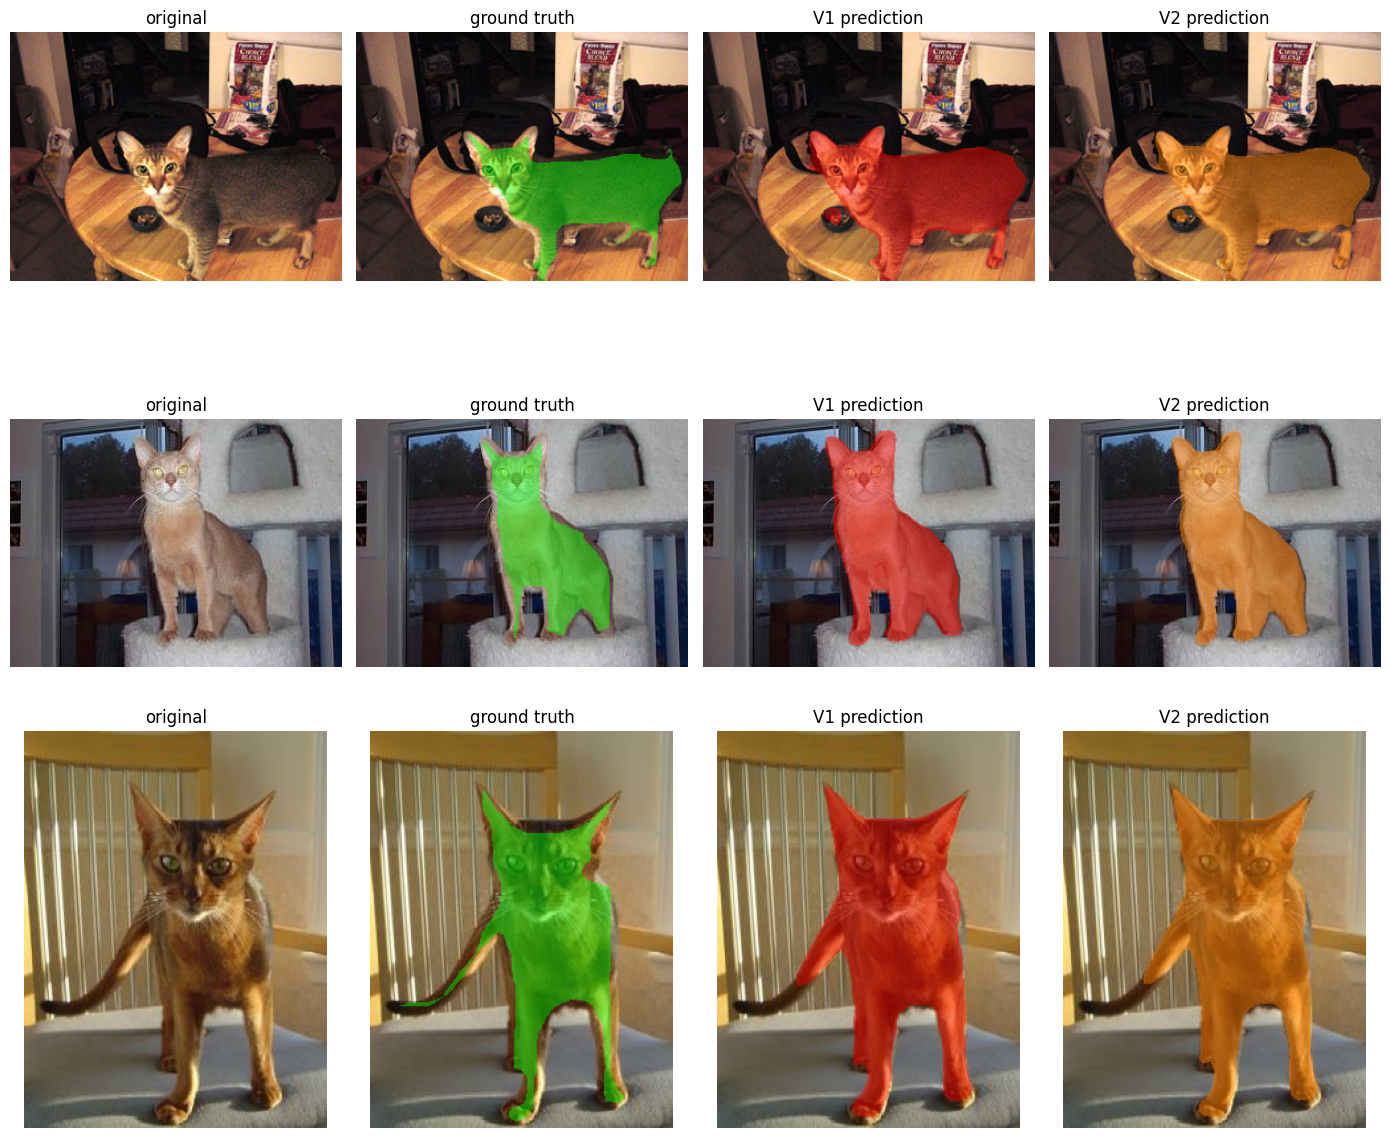

Saved: C:\Users\andre\OneDrive\Документы\DPO\AIE\AIE-1\homeworks\HW10-11\artifacts\figures\segmentation_examples.png


In [26]:
fig, axes = plt.subplots(3, 4, figsize=(14, 12))

for row_idx in range(3):
    ex1 = seg_v1["examples"][row_idx]
    ex2 = seg_v2["examples"][row_idx]

    axes[row_idx, 0].imshow(ex1["image"])
    axes[row_idx, 0].set_title("original")
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(overlay_mask(ex1["image"], ex1["gt"], color=(0, 255, 0), alpha=0.45))
    axes[row_idx, 1].set_title("ground truth")
    axes[row_idx, 1].axis("off")

    axes[row_idx, 2].imshow(overlay_mask(ex1["image"], ex1["pred"], color=(255, 0, 0), alpha=0.45))
    axes[row_idx, 2].set_title("V1 prediction")
    axes[row_idx, 2].axis("off")

    axes[row_idx, 3].imshow(overlay_mask(ex2["image"], ex2["pred"], color=(255, 128, 0), alpha=0.45))
    axes[row_idx, 3].set_title("V2 prediction")
    axes[row_idx, 3].axis("off")

plt.tight_layout()
plt.savefig(FIG_DIR / "segmentation_examples.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", FIG_DIR / "segmentation_examples.png")

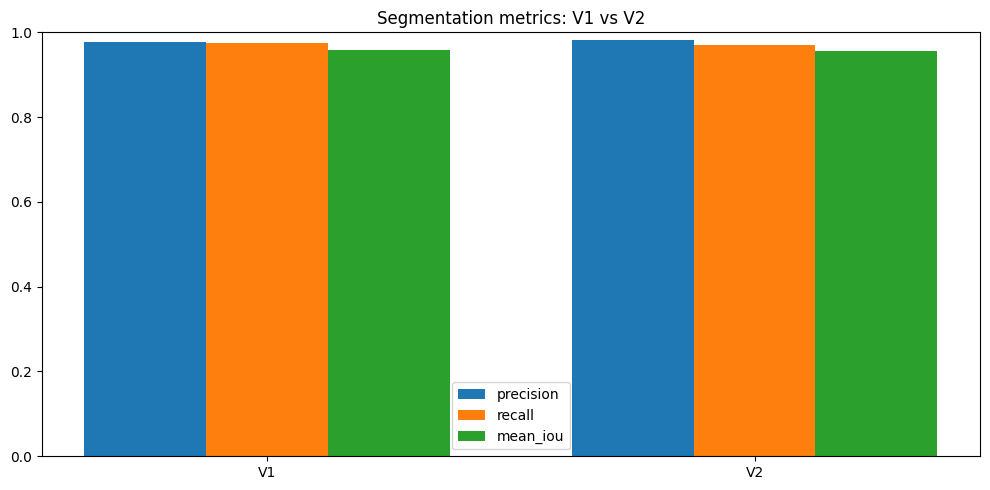

Saved: C:\Users\andre\OneDrive\Документы\DPO\AIE\AIE-1\homeworks\HW10-11\artifacts\figures\segmentation_metrics.png


In [27]:
seg_metrics_df = pd.DataFrame([
    {"experiment_id": "V1", "precision": seg_v1["precision"], "recall": seg_v1["recall"], "mean_iou": seg_v1["mean_iou"]},
    {"experiment_id": "V2", "precision": seg_v2["precision"], "recall": seg_v2["recall"], "mean_iou": seg_v2["mean_iou"]},
])

x = np.arange(len(seg_metrics_df))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, seg_metrics_df["precision"], width=width, label="precision")
plt.bar(x,         seg_metrics_df["recall"],    width=width, label="recall")
plt.bar(x + width, seg_metrics_df["mean_iou"],  width=width, label="mean_iou")

plt.xticks(x, seg_metrics_df["experiment_id"])
plt.ylim(0, 1)
plt.title("Segmentation metrics: V1 vs V2")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "segmentation_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", FIG_DIR / "segmentation_metrics.png")

In [28]:
segmentation_rows = [
    {
        "experiment_id": "V1",
        "task": "segmentation",
        "dataset": "OxfordIIITPet",
        "seed": SEED,
        "model_summary": "DeepLabV3_ResNet50 pretrained, cat+dog as foreground",
        "optimizer": "",
        "lr": np.nan,
        "epochs_trained": 0,
        "best_val_accuracy": np.nan,
        "test_accuracy": np.nan,
        "precision": seg_v1["precision"],
        "recall": seg_v1["recall"],
        "mean_iou": seg_v1["mean_iou"],
        "notes": "threshold=0.5, border ignored in metric",
    },
    {
        "experiment_id": "V2",
        "task": "segmentation",
        "dataset": "OxfordIIITPet",
        "seed": SEED,
        "model_summary": "DeepLabV3_ResNet50 pretrained, cat+dog as foreground",
        "optimizer": "",
        "lr": np.nan,
        "epochs_trained": 0,
        "best_val_accuracy": np.nan,
        "test_accuracy": np.nan,
        "precision": seg_v2["precision"],
        "recall": seg_v2["recall"],
        "mean_iou": seg_v2["mean_iou"],
        "notes": "threshold=0.6 + morphology, border ignored in metric",
    },
]

runs_df = pd.DataFrame(classification_rows + segmentation_rows)
runs_df.to_csv(ART_DIR / "runs.csv", index=False)

print(runs_df)
print("Saved:", ART_DIR / "runs.csv")

  experiment_id            task        dataset  seed  \
0            C1  classification          STL10    42   
1            C2  classification          STL10    42   
2            C3  classification          STL10    42   
3            C4  classification          STL10    42   
4            V1    segmentation  OxfordIIITPet    42   
5            V2    segmentation  OxfordIIITPet    42   

                                       model_summary optimizer      lr  \
0                        SimpleCNN, no augmentations      Adam  0.0010   
1                         SimpleCNN, augmented train      Adam  0.0010   
2      ResNet18 pretrained, backbone frozen, fc only      Adam  0.0010   
3         ResNet18 pretrained, layer4 + fc trainable      Adam  0.0001   
4  DeepLabV3_ResNet50 pretrained, cat+dog as fore...               NaN   
5  DeepLabV3_ResNet50 pretrained, cat+dog as fore...               NaN   

   epochs_trained  best_val_accuracy  test_accuracy  precision    recall  \
0           

In [29]:
print("Best classification experiment:", best_payload["experiment_id"], best_payload["name"])
print("Best val accuracy             :", best_payload["best_val_accuracy"])
print("Best test accuracy            :", best_test_metrics["accuracy"])
print()
print("Segmentation V1:", {k: v for k, v in seg_v1.items() if k != "examples"})
print("Segmentation V2:", {k: v for k, v in seg_v2.items() if k != "examples"})

Best classification experiment: C4 resnet18-finetune
Best val accuracy             : 0.95
Best test accuracy            : 0.94775

Segmentation V1: {'mean_iou': 0.9575971634010164, 'precision': 0.9783410864994126, 'recall': 0.9750239580570357, 'num_samples': 3669}
Segmentation V2: {'mean_iou': 0.9562603364399161, 'precision': 0.9813484201591546, 'recall': 0.9704335501788595, 'num_samples': 3669}
